In [1]:
import pandas as pd
import numpy as np
import random

In [2]:
# Пример DataFrame с группами
df_ = pd.DataFrame({'group': ['B', 'B', 'B', 'B', 'A', 'A', 'A', 'C', 'C', 'C', 'C', 'D', 'D', 'D', 'D', 'D'],
                    'values': [10, 30, 20, 30, 40, 40, 50, 10, 20, 30, 40, 30, np.nan, 20, np.nan, 10]}
                  )

In [3]:
# Пример DataFrame с группами
df_date = pd.DataFrame({
    'Category': ['A', 'A', 'A', 'B', 'B', 'B', 'A', 'A', 'B', 'B', 'A', 'A'],
    'Date': pd.date_range(start='2023-01-01', periods=12),
    'Sales': [10, np.nan, 30, 15, 25, 35, 40, 50, 60, 70, 0, 10]
                       }
                      )

#### 1. Классические оконные функции

**Сразу берем более сложный вариант вычисления внутри групп**

В библиотеке Pandas нет прямой реализации некоторых оконных функций, таких как, например, DENSE_RANK как в SQL  
но их можно эмулировать с помощью комбинации методов, например, rank и groupby.  

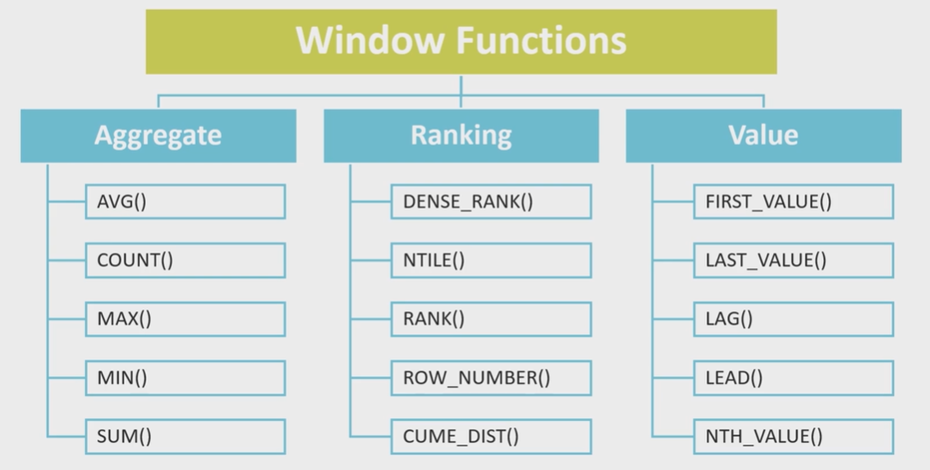

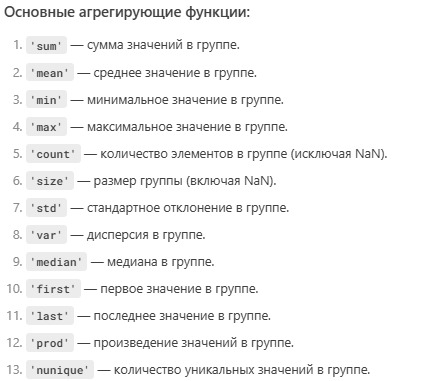

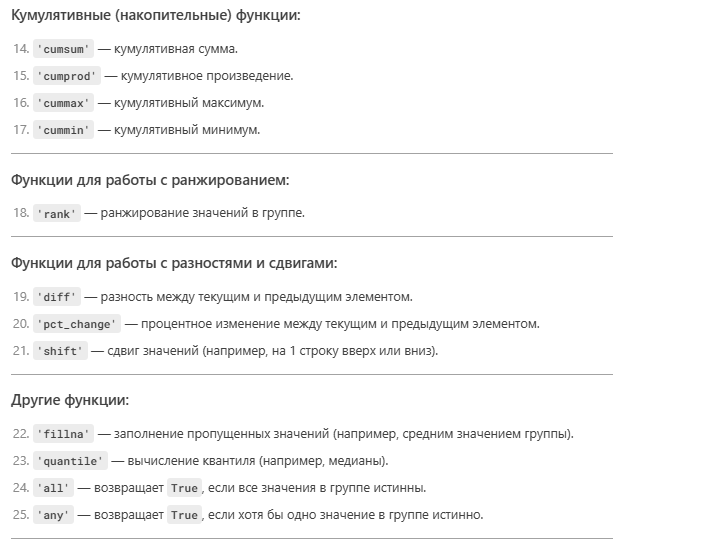

In [4]:
# Применяем аггрегирующие оконные функции

# MIN, AVG, MAX, COUNT, SUM - вот это и пользовательские удобнее всего...

# У остальных функционал ограничен будет, поэтому ранги и сдвиги считаем иначе

df = df_.copy()

# вот это как бы самый простой способ, тут почти все есть

df['Min'] = df.groupby('group')['values'].transform('min')
df['Avg'] = df.groupby('group')['values'].transform('mean')
df['Max'] = df.groupby('group')['values'].transform('max')
df['Count'] = df.groupby('group')['values'].transform('count')
df['Sum'] = df.groupby('group')['values'].transform('sum')
df['Std'] = df.groupby('group')['values'].transform('std')                  # стандартное отклонение
df['Var'] = df.groupby('group')['values'].transform('var')                  # дисперсия 

df['First'] = df.groupby('group')['values'].transform('first')              # первое - аналог head(1) ток на окно  
df['Last'] = df.groupby('group')['values'].transform('last')                # последнее - аналог tail(1) ток на окно

df['Prod'] = df.groupby('group')['values'].transform('prod')                # произведение значений в группе
df['Size'] = df.groupby('group')['values'].transform('size')                # размер - аналог count, но с нанами
df['Nunique'] = df.groupby('group')['values'].transform('nunique')          # кол-во уникальных значений в группе
df['Quantile'] = df.groupby('group')['values'].transform('quantile', q=0.5)


df['rank'] = df.groupby('group')['values'].transform('rank')                # ВОТ ЭТО НЕУДОБНО, ПОЭТОМУ ДЕЛАЕМ НЕ ТАК

# можно кастомные функции передавать, но тут еще нужно прям придумать что б это было полезно
# x - это группа, поэтому действие совершается уже над группой

df['fill_val'] = df.groupby('group')['values'].transform(lambda x: x.fillna(x.mean()))
df['Custom'] = df.groupby('group')['values'].transform(lambda x: min(x.index))                       # x - это группа - тут окно с минимальным индексом в группе

In [5]:
df

,group,values,Min,Avg,Max,Count,Sum,Std,Var,First,Last,Prod,Size,Nunique,Quantile,rank,fill_val,Custom
0,B,10.0,10.0,22.500000,30.0,4,90.0,9.574271,91.666667,10.0,30.0,180000.0,4,3,25.0,1.0,10.0,0
1,B,30.0,10.0,22.500000,30.0,4,90.0,9.574271,91.666667,10.0,30.0,180000.0,4,3,25.0,3.5,30.0,0
2,B,20.0,10.0,22.500000,30.0,4,90.0,9.574271,91.666667,10.0,30.0,180000.0,4,3,25.0,2.0,20.0,0
3,B,30.0,10.0,22.500000,30.0,4,90.0,9.574271,91.666667,10.0,30.0,180000.0,4,3,25.0,3.5,30.0,0
4,A,40.0,40.0,43.333333,50.0,3,130.0,5.773503,33.333333,40.0,50.0,80000.0,3,2,40.0,1.5,40.0,4
5,A,40.0,40.0,43.333333,50.0,3,130.0,5.773503,33.333333,40.0,50.0,80000.0,3,2,40.0,1.5,40.0,4
6,A,50.0,40.0,43.333333,50.0,3,130.0,5.773503,33.333333,40.0,50.0,80000.0,3,2,40.0,3.0,50.0,4
7,C,10.0,10.0,25.000000,40.0,4,100.0,12.909944,166.666667,10.0,40.0,240000.0,4,4,25.0,1.0,10.0,7
8,C,20.0,10.0,25.000000,40.0,4,100.0,12.909944,166.666667,10.0,40.0,240000.0,4,4,25.0,2.0,20.0,7
9,C,30.0,10.0,25.000000,40.0,4,100.0,12.909944,166.666667,10.0,40.0,240000.0,4,4,25.0,3.0,30.0,7


---

In [6]:
# RANK, DENSE_RANK, ROW_NUMBER

# Применяем ранжирующие оконные ф-ии внутри каждой группы

df = df_.copy()

# Ранги не любят пропуски, нужно допом заполнять, если есть
df['dense_rank'] = df.groupby('group')['values'].rank(method='dense').astype(float)       # Ранг без пропуска при повторении (ранжирование по возрастанию значений по умолч.)
df['rank'] = df.groupby('group')['values'].rank(method='min').astype(float)               # Ранг с пропуском при повторении

# df['row_num_rank'] = df.groupby('group')['values'].rank(method='first').astype(float)   # полный аналог row_number (НЕ СРАБОТАЛ С НАНОМ) вобще не оч удобно
df['row_num'] = df.groupby('group')['values'].cumcount() + 1                              # кумулятивный подсчет с 0, поэтому +1   == полный аналог row_number

In [7]:
df

,group,values,dense_rank,rank,row_num
0,B,10.0,1.0,1.0,1
1,B,30.0,3.0,3.0,2
2,B,20.0,2.0,2.0,3
3,B,30.0,3.0,3.0,4
4,A,40.0,1.0,1.0,1
5,A,40.0,1.0,1.0,2
6,A,50.0,2.0,3.0,3
7,C,10.0,1.0,1.0,1
8,C,20.0,2.0,2.0,2
9,C,30.0,3.0,3.0,3


---

In [8]:
# LAG, LEAD

# Применяем оконные функции смещения

df = df_.copy()

df['shift_down'] = df.groupby('group')['values'].shift(1, fill_value=None)       # колонка со сдвигом вниз
df['shift_up'] = df.groupby('group')['values'].shift(-1)                         # колонка со сдвигом вверх

In [9]:
df

,group,values,shift_down,shift_up
0,B,10.0,NaN,30.0
1,B,30.0,10.0,20.0
2,B,20.0,30.0,30.0
3,B,30.0,20.0,NaN
4,A,40.0,NaN,40.0
5,A,40.0,40.0,50.0
6,A,50.0,40.0,NaN
7,C,10.0,NaN,20.0
8,C,20.0,10.0,30.0
9,C,30.0,20.0,40.0


#### 2. Функция вычисления разницы между текущей записью и предыдущими

**Сразу берем более сложный вариант вычисления внутри групп**

In [10]:
df = df_.copy()

df['diff_1'] = df.groupby('group')['values'].diff(periods=1, axis=0)          # значения по умолчанию, (axis=1 можно вычислить послед разность меж колонками)
df['diff_2'] = df.groupby('group')['values'].diff(periods=2)

In [11]:
df

,group,values,diff_1,diff_2
0,B,10.0,NaN,NaN
1,B,30.0,20.0,NaN
2,B,20.0,-10.0,10.0
3,B,30.0,10.0,0.0
4,A,40.0,NaN,NaN
5,A,40.0,0.0,NaN
6,A,50.0,10.0,10.0
7,C,10.0,NaN,NaN
8,C,20.0,10.0,NaN
9,C,30.0,10.0,20.0


In [12]:
# для примера, можно применить ко всему df

#df.iloc[:, -3:].diff(axis=1)

#### 3. Функция с задаваемым окном (скользящие вычисления)

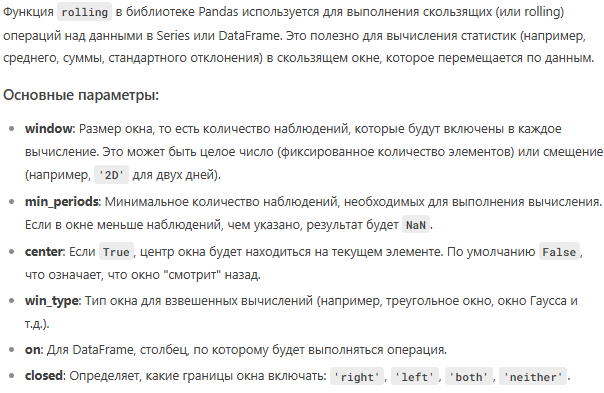

In [13]:
# важно!!!  можно размер окна выставить по периоду времени, а не по количеству записей

In [14]:
# важно!!! rolling перемешивает все индексы внутри групп, поэтому он сам по себе возвращает измененный датасет - НЕУДОБНО

In [15]:
df = df_.copy()

df.shape

(16, 2)

In [16]:
df

,group,values
0,B,10.0
1,B,30.0
2,B,20.0
3,B,30.0
4,A,40.0
5,A,40.0
6,A,50.0
7,C,10.0
8,C,20.0
9,C,30.0


In [17]:
# Если без группировки, то можно сделать удобно новый столбик (Наны не учтутся)

df['window_mean_1'] = df['values'].rolling(window=5, min_periods=2).mean()  
df['window_mean_2'] = df['values'].rolling(window=5, min_periods=5).mean()

In [18]:
# Скользящее среднее по группам

df['window_mean_group'] = df.groupby('group')['values'] \
                            .rolling(window=2, min_periods=1) \
                            .mean() \
                            .reset_index(level=0, drop=True)     # level=0 выравнивает индексы с исходным df (недоконца понятно почему level=0 работает, но работает)

# это как бы накопительная сумма, но для окна в 2 строки

df['window_sum_group'] = df.groupby('group')['values'] \
                           .rolling(window=2, min_periods=1) \
                           .sum() \
                           .reset_index(level=0, drop=True)     # level=0 выравнивает индексы с исходным df (недоконца понятно почему level=0 работает, но работает)

In [19]:
df

,group,values,window_mean_1,window_mean_2,window_mean_group,window_sum_group
0,B,10.0,NaN,NaN,10.0,10.0
1,B,30.0,20.0,NaN,20.0,40.0
2,B,20.0,20.0,NaN,25.0,50.0
3,B,30.0,22.5,NaN,25.0,50.0
4,A,40.0,26.0,26.0,40.0,40.0
5,A,40.0,32.0,32.0,40.0,80.0
6,A,50.0,36.0,36.0,45.0,90.0
7,C,10.0,34.0,34.0,10.0,10.0
8,C,20.0,32.0,32.0,15.0,30.0
9,C,30.0,30.0,30.0,25.0,50.0


In [20]:
# Пример расчета скользящего окна с датой      НЕ РАБОТАЕТ У МЕНЯ...

df = df_date.copy()

# при расчете с окном по дате все то же самое, только в качестве индекса нужны даты 



#### 4. Кумулятивные рассчеты

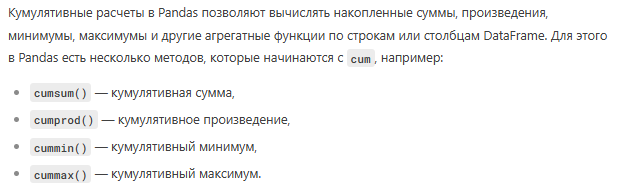

In [27]:
df = df_.copy()

df['cumcount_group'] = df.groupby('group')['values'].cumcount()          # начинается с 0
df['cumsum_group'] = df.groupby('group')['values'].cumsum()              # В нанах пишет Нан, но сумму считает
df['cummax_group'] = df.groupby('group')['values'].cummax() 
df['cumprod_group'] = df.groupby('group')['values'].cumprod() 

# есть еще накопительное среднее, которое почему-то считается отдельно вот так

df['cummean_group'] = df.groupby('group')['values'].expanding().mean().reset_index(level=0, drop=True)

In [28]:
# Накопление сработает и по строке, просто для примера посчитаем сумму по строке
# cumsum сам по себе посчитает на каждый столбец а потом можно взять последний столбец

df['cumsum_row'] = df.iloc[:, 1:].cumsum(axis=1).iloc[:, -1]

In [30]:
df

,group,values,cumcount_group,cumsum_group,cummax_group,cumprod_group,cummean_group,cumsum_row
0,B,10.0,0,10.0,10.0,10.0,10.000000,50.000000
1,B,30.0,1,40.0,30.0,300.0,20.000000,421.000000
2,B,20.0,2,60.0,30.0,6000.0,20.000000,6132.000000
3,B,30.0,3,90.0,30.0,180000.0,22.500000,180175.500000
4,A,40.0,0,40.0,40.0,40.0,40.000000,200.000000
5,A,40.0,1,80.0,40.0,1600.0,40.000000,1801.000000
6,A,50.0,2,130.0,50.0,80000.0,43.333333,80275.333333
7,C,10.0,0,10.0,10.0,10.0,10.000000,50.000000
8,C,20.0,1,30.0,20.0,200.0,15.000000,286.000000
9,C,30.0,2,60.0,30.0,6000.0,20.000000,6142.000000


#### 5. Пользовательские оконные функции

In [31]:
df = df_.copy()

In [32]:
df['custom_nan'] = df.groupby('group')['values'].transform(lambda x: x.isnull().sum() / x.shape[0])       # так мы можем посчитать, например, долю нанов в группе
df['custom_max_count'] = df.groupby('group')['values'].transform(lambda x: (x == x.max()).sum())          # количесвто записей в группе равных максимальному значению в группе

In [33]:
df

,group,values,custom_nan,custom_max_count
0,B,10.0,0.0,2
1,B,30.0,0.0,2
2,B,20.0,0.0,2
3,B,30.0,0.0,2
4,A,40.0,0.0,1
5,A,40.0,0.0,1
6,A,50.0,0.0,1
7,C,10.0,0.0,1
8,C,20.0,0.0,1
9,C,30.0,0.0,1
